# Conjuntos Numéricos

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`011a_nocoes_de_logica.ipynb`](011a_nocoes_de_logica.ipynb) e [`012a_conjuntos.ipynb`](012a_conjuntos.ipynb), além do Python básico de [00_fundamentos_e_python/](../00_fundamentos_e_python/)

**Objetivos de aprendizagem:**
- Reconhecer e diferenciar os conjuntos N, Z, Q, R e C, e entender por que cada um foi criado.
- Representar e interpretar intervalos na reta real.
- Compreender e aplicar o princípio da indução finita em demonstrações simples.
- Localizar números racionais e irracionais na reta numérica e reconhecer dízimas periódicas.

**Tempo estimado:** 45 a 60 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/013a_conjuntos_numericos.ipynb)

## Uma equação que não para de travar

Tente "resolver" cada uma dessas equações, uma de cada vez, só de cabeça:

1. `x + 5 = 3`
2. `2x = 3`
3. `x² = 2`
4. `x² = -1`

Se você parou em alguma delas, não é falta de habilidade — é que, em algum ponto, a equação simplesmente **não tem solução dentro do conjunto de números que você estava usando ou que você conhece até o momento**. A primeira trava ocorre se você só conhece números de contar. A segunda trava se você não admite frações. A terceira trava se você não admite números "que não terminam nem repetem". A quarta trava mesmo para qualquer número que você consiga marcar numa régua.

💡 **Dica:** cada vez que a matemática esbarra numa parede dessas, ela inventa um número novo para atravessar. Guarde essas quatro equações — cada bloco a seguir deste notebook resolve uma delas, na ordem.

## Números Naturais (N)

- Os **números naturais** nasceram da necessidade mais básica da matemática: **contar**. N = {0, 1, 2, 3, 4, ...}.
- ⚠️ **Erro comum:** achar que existe só uma convenção sobre o zero. Em alguns livros (e na norma ISO), N = {0, 1, 2, ...}; em outros, N = {1, 2, 3, ...} e o zero fica de fora. Vamos usar a convenção **com zero** neste curso, mas deixe claro qual você está usando ao resolver um problema.
- N é o único conjunto numérico **sem números negativos e sem frações** — e é o único que é sempre suficiente para resolver `x + 5 = 3`... seria, se a resposta não desse -2.

📌 **Definição formal:**
- Wikipédia (PT): ["Número natural"](https://pt.wikipedia.org/wiki/N%C3%BAmero_natural)

**Pergunta de checagem:**
1. N tem elemento máximo? N é um conjunto infinito?

In [1]:
def eh_natural(x) -> bool:
    '''Verifica se x é um número natural (inteiro maior ou igual a zero).'''
    return isinstance(x, int) and x >= 0


for candidato in [5, -3, 2.5, 0]:
    print(f"{candidato} ∈ N? {eh_natural(candidato)}")

5 ∈ N? True
-3 ∈ N? False
2.5 ∈ N? False
0 ∈ N? True


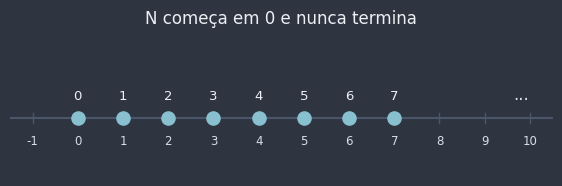

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"


def reta_numerica(
    pontos: list[tuple[float, str]] | None = None,
    intervalo: tuple[float, float, bool, bool] | None = None,
    segmento: tuple[float, float] | None = None,
    limites: tuple[float, float] = (-6, 6),
    nota: str | None = None,
    titulo: str = "",
    ax=None,
) -> None:
    '''Desenha uma reta numérica com pontos, um intervalo e/ou um segmento destacados.

    Este componente reaparece, sem mudanças, em várias seções seguintes deste
    notebook (inteiros, reais/módulo e intervalos) — só o que é passado como
    argumento muda.

    Args:
        pontos: lista de (valor, rótulo) marcados como bolinhas cheias na reta.
        intervalo: (a, b, fechado_em_a, fechado_em_b) — desenha o segmento
            [a, b], com bolinha cheia nas pontas fechadas e vazia nas abertas.
        segmento: (a, b) — traça uma linha grossa entre a e b, útil para
            ilustrar a distância (módulo) entre dois pontos.
        limites: intervalo (mínimo, máximo) exibido no eixo horizontal.
        nota: texto livre exibido perto da extremidade direita (ex.: "...").
        titulo: título exibido acima da reta.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(7, 1.8))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    minimo, maximo = limites
    ax.axhline(0, color=NORD_LINHA, linewidth=1.5, zorder=1)
    for x in range(int(np.ceil(minimo)), int(np.floor(maximo)) + 1):
        ax.plot([x, x], [-0.06, 0.06], color=NORD_LINHA, linewidth=1, zorder=1)
        ax.text(x, -0.3, str(x), color=NORD_TEXTO_SEC, fontsize=8.5, ha="center")

    if intervalo is not None:
        a, b, fechado_a, fechado_b = intervalo
        ax.plot([a, b], [0, 0], color=COR_DESTAQUE, linewidth=4, zorder=2)
        ax.scatter(
            [a], [0], s=90, zorder=3,
            facecolor=COR_DESTAQUE if fechado_a else NORD_FUNDO,
            edgecolor=COR_DESTAQUE, linewidth=2,
        )
        ax.scatter(
            [b], [0], s=90, zorder=3,
            facecolor=COR_DESTAQUE if fechado_b else NORD_FUNDO,
            edgecolor=COR_DESTAQUE, linewidth=2,
        )

    if segmento is not None:
        a, b = segmento
        ax.plot([a, b], [0.42, 0.42], color=COR_ALERTA, linewidth=2.5, zorder=2)
        ax.plot([a, a], [0, 0.42], color=COR_ALERTA, linewidth=1, linestyle=":", zorder=2)
        ax.plot([b, b], [0, 0.42], color=COR_ALERTA, linewidth=1, linestyle=":", zorder=2)
        ax.scatter([a, b], [0, 0], s=70, color=COR_ALERTA, zorder=3)
        ax.text(
            (a + b) / 2, 0.58, f"|{a:g} − {b:g}| = {abs(a - b):g}",
            color=NORD_TEXTO, fontsize=9.5, ha="center",
        )

    if pontos is not None:
        for valor, rotulo in pontos:
            ax.scatter([valor], [0], s=90, color=COR_PONTO, zorder=4)
            ax.text(valor, 0.2, rotulo, color=NORD_TEXTO, fontsize=9.5, ha="center")

    if nota:
        ax.text(maximo - 0.2, 0.2, nota, color=NORD_TEXTO_SEC, fontsize=12, ha="center")

    ax.set_xlim(minimo - 0.5, maximo + 0.5)
    ax.set_ylim(-0.65, 0.9)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=10)

    if criou_figura:
        plt.show()


primeiros_naturais = list(range(8))
reta_numerica(
    [(n, str(n)) for n in primeiros_naturais],
    limites=(-1, 10),
    nota="...",
    titulo="N começa em 0 e nunca termina",
)

## Princípio da Indução Finita

Como provar que uma afirmação vale para **todo** número natural, se são infinitos e você não pode testar um por um?

- **Ideia:** é como uma fileira infinita de dominós. Se você garante que (1) o primeiro dominó cai (**base**), e que (2) sempre que um dominó cai, o próximo também cai (**passo indutivo**), então **todos** os dominós caem — não importa quantos sejam.
- A **base** verifica a afirmação para o menor caso (geralmente n = 0 ou n = 1).
- O **passo indutivo** assume que a afirmação vale para um k genérico (**hipótese de indução**) e prova que, a partir disso, ela também vale para k + 1.

📌 **Definição formal:**
- Wikipédia (PT): ["Indução matemática"](https://pt.wikipedia.org/wiki/Indu%C3%A7%C3%A3o_matem%C3%A1tica)

⚠️ **Erro comum:** confundir "testei a fórmula para vários valores de n e sempre deu certo" com "provei que vale para todo n". Testar dá **evidência forte**, mas só a indução (base + passo) garante a certeza para o infinito inteiro.

🕵️ **Curiosidade histórica:** o princípio já aparecia (informalmente) em matemáticos como Euclides e Pascal, mas foi formalizado como um dos **axiomas de Peano** para os números naturais, no final do século XIX — uma das bases de toda a matemática moderna.

**Pergunta de checagem:**
1. Na prova a seguir, identifique claramente qual parte é a base e qual é o passo indutivo.

In [4]:
def soma_direta(n: int) -> int:
    '''Soma 1 + 2 + ... + n, somando os termos um a um.'''
    return sum(range(1, n + 1))


def soma_formula(n: int) -> int:
    '''Soma 1 + 2 + ... + n, usando a fórmula fechada n(n + 1) / 2.'''
    return n * (n + 1) // 2


for n in [1, 2, 5, 10, 50, 100]:
    direta, formula = soma_direta(n), soma_formula(n)
    print(f"n={n:>3}: soma direta = {direta:>5} | fórmula = {formula:>5} | iguais? {direta == formula}")

n=  1: soma direta =     1 | fórmula =     1 | iguais? True
n=  2: soma direta =     3 | fórmula =     3 | iguais? True
n=  5: soma direta =    15 | fórmula =    15 | iguais? True
n= 10: soma direta =    55 | fórmula =    55 | iguais? True
n= 50: soma direta =  1275 | fórmula =  1275 | iguais? True
n=100: soma direta =  5050 | fórmula =  5050 | iguais? True


A tabela acima só dá **evidência** — testamos 6 valores de n, mas N tem infinitos. A prova de verdade usa indução:

**Afirmação:** para todo n natural (n ≥ 1), 1 + 2 + ... + n = n(n + 1) / 2.

**Base (n = 1):** o lado esquerdo é 1. O lado direito é 1(1 + 1) / 2 = 1. Os dois batem. ✅

**Passo indutivo:** suponha que a afirmação vale para um k qualquer (hipótese de indução):

> 1 + 2 + ... + k = k(k + 1) / 2

Queremos provar que ela também vale para k + 1, ou seja, que 1 + 2 + ... + k + (k + 1) = (k + 1)(k + 2) / 2. Partindo do lado esquerdo e usando a hipótese de indução:

> 1 + 2 + ... + k + (k + 1) = k(k + 1) / 2 + (k + 1) = (k + 1) · [k / 2 + 1] = (k + 1)(k + 2) / 2

Que é exatamente o que queríamos provar. ✅

Como a base vale e o passo indutivo vale, o **Princípio da Indução Finita** garante que a fórmula é verdadeira para **todo** n natural — não só para os 6 valores que testamos no código.

## Números Inteiros (Z)

- A equação `x + 5 = 3` não tem solução em N, porque a solução é x = -2, e N não tem números negativos.
- Os **números inteiros** resolvem isso: incluem os naturais, seus opostos negativos, e o zero. Z = {..., -3, -2, -1, 0, 1, 2, 3, ...}.
- Todo número natural é inteiro, ou seja, **N ⊂ Z** — mas a volta não vale (-2 é inteiro e não é natural).

📌 **Definição formal:**
- Wikipédia (PT): ["Número inteiro"](https://pt.wikipedia.org/wiki/N%C3%BAmero_inteiro)

**Pergunta de checagem:**
1. Toda subtração entre dois números naturais resulta em um número inteiro? E o resultado é sempre natural também?

x + 5 = 3  ->  x = -2
-2 ∈ N? False
-2 ∈ Z? True


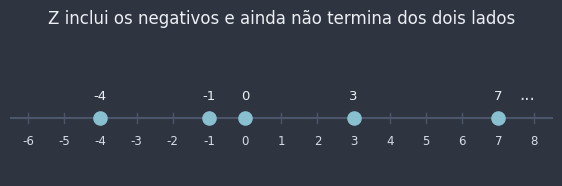

In [5]:
def eh_inteiro(x) -> bool:
    '''Verifica se x é um número inteiro (positivo, negativo ou zero).'''
    return isinstance(x, int)


x = 3 - 5  # resolvendo x + 5 = 3
print("x + 5 = 3  ->  x =", x)
print(f"{x} ∈ N? {eh_natural(x)}")
print(f"{x} ∈ Z? {eh_inteiro(x)}")

inteiros_exemplo = [-4, -1, 0, 3, 7]
reta_numerica(
    [(z, str(z)) for z in inteiros_exemplo],
    limites=(-6, 8),
    nota="...",
    titulo="Z inclui os negativos e ainda não termina dos dois lados",
)

## Números Racionais (Q)

- A equação `2x = 3` não tem solução em Z, porque a solução é x = 3/2, e Z não tem frações.
- Os **números racionais** são todos os que podem ser escritos como uma fração a/b, com a e b inteiros e b ≠ 0. Todo inteiro é racional (basta usar b = 1), ou seja, **Z ⊂ Q**.
- Toda fração, ao ser convertida para decimal, gera um decimal **finito** (termina) ou uma **dízima periódica** (um bloco de dígitos que se repete para sempre).

📌 **Definição formal:**
- Wikipédia (PT): ["Número racional"](https://pt.wikipedia.org/wiki/N%C3%BAmero_racional)

⚠️ **Erro comum:** achar que **toda** dízima (decimal infinito) é racional. Isso só vale para dízimas **periódicas** — guarde essa ressalva, ela é o gancho do próximo bloco.

**Pergunta de checagem:**
1. 0,333... é racional? Por quê?

In [6]:
from fractions import Fraction


def expandir_decimal(numerador: int, denominador: int, casas: int = 20) -> str:
    '''Gera a expansão decimal de numerador/denominador por divisão longa.

    Diferente de simplesmente converter para float, a divisão longa produz os
    dígitos reais da divisão, permitindo enxergar o período de uma dízima se
    repetindo (um float arredonda e pode esconder o padrão).

    Args:
        numerador: numerador da fração.
        denominador: denominador da fração (≠ 0).
        casas: quantidade de casas decimais a gerar.

    Returns:
        String no formato "parte_inteira,casas_decimais".
    '''
    inteiro, resto = divmod(abs(numerador), denominador)
    digitos = []
    for _ in range(casas):
        resto *= 10
        digito, resto = divmod(resto, denominador)
        digitos.append(str(digito))
    sinal = "-" if numerador < 0 else ""
    return f"{sinal}{inteiro},{''.join(digitos)}"


for num, den in [(1, 2), (1, 3), (2, 7), (3, 4), (1, 6)]:
    fracao = Fraction(num, den)
    print(f"{num}/{den} = {expandir_decimal(num, den, 15)}...   (fração simplificada: {fracao})")

1/2 = 0,500000000000000...   (fração simplificada: 1/2)
1/3 = 0,333333333333333...   (fração simplificada: 1/3)
2/7 = 0,285714285714285...   (fração simplificada: 2/7)
3/4 = 0,750000000000000...   (fração simplificada: 3/4)
1/6 = 0,166666666666666...   (fração simplificada: 1/6)


Repare no padrão: 1/2 e 3/4 "terminam" (na verdade, viram uma sequência infinita de zeros). Já 1/3, 2/7 e 1/6 entram em um **ciclo** de dígitos que se repete para sempre — é a **dízima periódica**.

Use o widget abaixo para testar outras frações e observar a expansão decimal gerada.

In [7]:
import ipywidgets as widgets


def explorar_fracao(numerador: int, denominador: int) -> None:
    if denominador == 0:
        print("O denominador não pode ser zero!")
        return
    fracao = Fraction(numerador, denominador)
    print(f"{numerador}/{denominador} = {fracao} (forma simplificada)")
    print(f"Expansão decimal: {expandir_decimal(numerador, denominador, 20)}...")


widgets.interact(
    explorar_fracao,
    numerador=widgets.IntSlider(value=1, min=-20, max=20, description="numerador:"),
    denominador=widgets.IntSlider(value=3, min=1, max=20, description="denominador:"),
)

interactive(children=(IntSlider(value=1, description='numerador:', max=20, min=-20), IntSlider(value=3, descri…

<function __main__.explorar_fracao(numerador: int, denominador: int) -> None>

## Números Irracionais

A equação `x² = 2` não tem solução racional. Vamos provar isso — ou seja, provar que **√2 é irracional** — com uma prova por contradição, passo a passo:

1. Suponha, por contradição, que √2 **é** racional. Então √2 = p/q, com p e q inteiros, q ≠ 0, e a fração **já simplificada ao máximo** (mdc(p, q) = 1).
2. Elevando os dois lados ao quadrado: 2 = p² / q², ou seja, **p² = 2q²**.
3. Isso significa que p² é par. Se p² é par, então **p também é par** (o quadrado de um ímpar é sempre ímpar). Logo, p = 2k para algum inteiro k.
4. Substituindo: (2k)² = 2q² → 4k² = 2q² → **q² = 2k²**. Pelo mesmo argumento do passo 3, **q também é par**.
5. Mas se p e q são **ambos pares**, eles têm o fator 2 em comum — contradizendo a suposição de que a fração já estava simplificada ao máximo!
6. Essa contradição mostra que a suposição inicial (√2 ser racional) está errada. Logo, **√2 é irracional**.

🕵️ **Curiosidade histórica:** essa descoberta gerou uma verdadeira crise na escola pitagórica, que acreditava que "tudo é número" (racional). Segundo a lenda, o pitagórico Hipaso de Metaponto teria sido afogado por revelar essa prova, que contradizia o dogma da escola.

📌 **Definição formal:** um número **irracional** é aquele que **não pode** ser escrito como fração de inteiros — sua expansão decimal é infinita e **não periódica**, sem nenhum bloco de dígitos que se repita para sempre.

**Pergunta de checagem:**
1. π é racional ou irracional? E 1/3?

In [8]:
import sympy

raiz_de_2 = sympy.sqrt(2).evalf(50)
pi_aproximado = sympy.pi.evalf(50)

print("√2 ≈", raiz_de_2)
print("π  ≈", pi_aproximado)
print()
print(
    "Em nenhuma das duas expansões acima aparece um bloco de dígitos se repetindo -- "
    "é exatamente o que esperamos de um número irracional."
)

√2 ≈ 1.4142135623730950488016887242096980785696718753769
π  ≈ 3.1415926535897932384626433832795028841971693993751

Em nenhuma das duas expansões acima aparece um bloco de dígitos se repetindo -- é exatamente o que esperamos de um número irracional.


## Números Reais (R)

- Juntando os racionais com os irracionais, obtemos os **números reais**: **R = Q ∪ {irracionais}**. Como Q ⊂ R, temos a cadeia **N ⊂ Z ⊂ Q ⊂ R**.
- Intuitivamente, os reais **preenchem completamente** a reta numérica: todo ponto da reta corresponde a exatamente um número real, e vice-versa — não sobram "buracos" como em Q (onde √2 seria um buraco).
- **Módulo (valor absoluto)** de um número x, escrito |x|, é a **distância de x até o zero** na reta — sempre um valor não negativo.

📌 **Definição formal:** |x| = x, se x ≥ 0; e |x| = -x, se x < 0.

**Pergunta de checagem:**
1. |−7| = ? Qual a distância entre -3 e 5, usando módulo?

In [9]:
def modulo(x: float) -> float:
    '''Calcula o módulo (valor absoluto) de x: a distância de x até 0.'''
    return x if x >= 0 else -x


for valor in [-7, 7, -3.5, 0]:
    print(f"|{valor}| = {modulo(valor)}   (confere com abs(): {modulo(valor) == abs(valor)})")

distancia = modulo(-3 - 5)
print(f"\nDistância entre -3 e 5: |−3 − 5| = {distancia}")

|-7| = 7   (confere com abs(): True)
|7| = 7   (confere com abs(): True)
|-3.5| = 3.5   (confere com abs(): True)
|0| = 0   (confere com abs(): True)

Distância entre -3 e 5: |−3 − 5| = 8


In [10]:
def explorar_modulo(x: float) -> None:
    reta_numerica(segmento=(0, x), limites=(-8, 8), titulo=f"|{x:g}| = distância de {x:g} até 0")
    print(f"|{x}| = {modulo(x)}")


widgets.interact(
    explorar_modulo,
    x=widgets.FloatSlider(value=-4, min=-8, max=8, step=0.5, description="x:"),
)

interactive(children=(FloatSlider(value=-4.0, description='x:', max=8.0, min=-8.0, step=0.5), Output()), _dom_…

<function __main__.explorar_modulo(x: float) -> None>

## Intervalos

- Um **intervalo** é um subconjunto de R formado por todos os números entre dois extremos a e b (com a < b). A notação muda conforme os extremos entram ou não no intervalo:

| Notação | Nome | Significado |
|---|---|---|
| (a, b) | aberto | a < x < b (nenhum extremo entra) |
| [a, b] | fechado | a ≤ x ≤ b (os dois extremos entram) |
| [a, b) | semiaberto à direita | a ≤ x < b (só o esquerdo entra) |
| (a, b] | semiaberto à esquerda | a < x ≤ b (só o direito entra) |
| (a, +∞), (-∞, a) | infinito | um dos lados (ou os dois) não tem limite |

📌 **Definição formal:**
- Wikipédia (PT): ["Intervalo (matemática)"](https://pt.wikipedia.org/wiki/Intervalo_(matem%C3%A1tica))

**Aplicação prática:** intervalos aparecem toda vez que existe uma faixa de valores válidos — o domínio de uma função, uma faixa de idade permitida, uma faixa de temperatura segura para um equipamento, etc.

**Pergunta de checagem:**
1. O número 3 pertence a (3, 8]? E a [3, 8)?

In [12]:
from typing import Literal

IntervaloTipo = Literal["aberto", "fechado", "semiaberto_direita", "semiaberto_esquerda"]


def pertence_ao_intervalo(x: float, a: float, b: float, tipo: IntervaloTipo) -> bool:
    '''Verifica se x pertence ao intervalo de extremos a e b, do tipo dado.'''
    if tipo == "aberto":
        return a < x < b
    if tipo == "fechado":
        return a <= x <= b
    if tipo == "semiaberto_direita":  # [a, b)
        return a <= x < b
    if tipo == "semiaberto_esquerda":  # (a, b]
        return a < x <= b
    raise ValueError(f"Tipo de intervalo desconhecido: {tipo}")


print("3 ∈ (3, 8]?", pertence_ao_intervalo(3, 3, 8, "semiaberto_esquerda"))
print("3 ∈ [3, 8)?", pertence_ao_intervalo(3, 3, 8, "semiaberto_direita"))
print("8 ∈ (3, 8]?", pertence_ao_intervalo(8, 3, 8, "semiaberto_esquerda"))

print("\nIntervalo infinito, ex.: [3, +∞)")
print("1000 ∈ [3, +∞)?", pertence_ao_intervalo(1000, 3, float("inf"), "semiaberto_direita"))
print("-5 ∈ [3, +∞)?  ", pertence_ao_intervalo(-5, 3, float("inf"), "semiaberto_direita"))

3 ∈ (3, 8]? False
3 ∈ [3, 8)? True
8 ∈ (3, 8]? True

Intervalo infinito, ex.: [3, +∞)
1000 ∈ [3, +∞)? True
-5 ∈ [3, +∞)?   False


In [13]:
NOTACAO_INTERVALO = {
    "aberto": lambda a, b: f"({a:g}, {b:g})",
    "fechado": lambda a, b: f"[{a:g}, {b:g}]",
    "semiaberto_direita": lambda a, b: f"[{a:g}, {b:g})",
    "semiaberto_esquerda": lambda a, b: f"({a:g}, {b:g}]",
}

FECHADO_NAS_PONTAS = {
    "aberto": (False, False),
    "fechado": (True, True),
    "semiaberto_direita": (True, False),
    "semiaberto_esquerda": (False, True),
}


def explorar_intervalo(a: float, b: float, tipo: IntervaloTipo) -> None:
    if a >= b:
        print("O extremo esquerdo deve ser menor que o direito.")
        return
    fechado_a, fechado_b = FECHADO_NAS_PONTAS[tipo]
    notacao = NOTACAO_INTERVALO[tipo](a, b)
    reta_numerica(intervalo=(a, b, fechado_a, fechado_b), limites=(-10, 10), titulo=notacao)
    for teste in [a - 1, a, (a + b) / 2, b, b + 1]:
        print(f"{teste:g} ∈ {notacao}? {pertence_ao_intervalo(teste, a, b, tipo)}")


widgets.interact(
    explorar_intervalo,
    a=widgets.FloatSlider(value=-2, min=-10, max=10, step=1, description="a:"),
    b=widgets.FloatSlider(value=5, min=-10, max=10, step=1, description="b:"),
    tipo=widgets.ToggleButtons(options=list(NOTACAO_INTERVALO.keys()), value="fechado", description="tipo:"),
)

interactive(children=(FloatSlider(value=-2.0, description='a:', max=10.0, min=-10.0, step=1.0), FloatSlider(va…

<function __main__.explorar_intervalo(a: float, b: float, tipo: Literal['aberto', 'fechado', 'semiaberto_direita', 'semiaberto_esquerda']) -> None>

## Números Complexos (C) — uma porta entreaberta

A equação `x² = -1` não tem solução em R — o quadrado de qualquer número real é sempre maior ou igual a zero, nunca negativo. Nenhum ponto da reta real resolve essa equação.

📌 Mas existe um conjunto numérico maior onde essa equação **tem** solução: os **números complexos**, C, com **R ⊂ C**. Aqui vamos deixar só essa porta entreaberta, sem entrar em forma algébrica, na unidade imaginária i, ou em operações — isso fica para outro momento.

📎 **Conexão:** isso será aprofundado no módulo [`09_complexos_polinomios_e_equacoes/`](../09_complexos_polinomios_e_equacoes/).

## Resumo

- **Cadeia de inclusão:** N ⊂ Z ⊂ Q ⊂ R ⊂ C

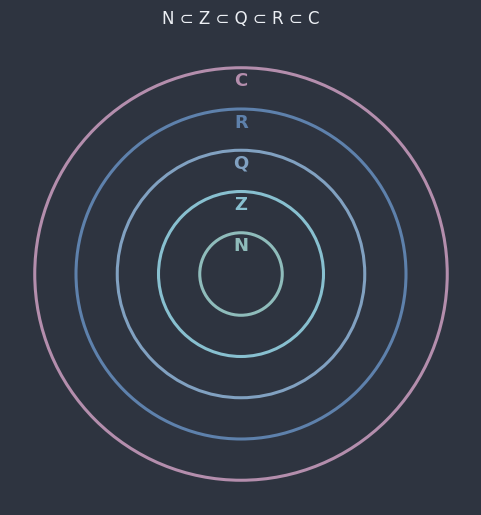

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)

conjuntos_aninhados = [
    ("C", 2.5, "#B48EAD"),
    ("R", 2.0, "#5E81AC"),
    ("Q", 1.5, "#81A1C1"),
    ("Z", 1.0, "#88C0D0"),
    ("N", 0.5, "#8FBCBB"),
]

for nome, raio, cor in conjuntos_aninhados:
    ax.add_patch(plt.Circle((0, 0), raio, facecolor="none", edgecolor=cor, linewidth=2.2))
    ax.text(0, raio - 0.22, nome, color=cor, fontsize=13, ha="center", fontweight="bold")

ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-2.8, 2.8)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("N ⊂ Z ⊂ Q ⊂ R ⊂ C", color=NORD_TEXTO, pad=14)
plt.show()

| Conjunto | O que ele resolve | Exemplo de elemento |
|---|---|---|
| N | contar | 0, 1, 2, 3, ... |
| Z | subtração sem restrição (x + 5 = 3) | -5, 0, 7 |
| Q | divisão sem restrição (2x = 3) | 1/2, -3/4 |
| R | preencher os "buracos" da reta (x² = 2) | √2, π |
| C | raízes de números negativos (x² = -1) | resolve x² = -1 |

**Intervalos:** (a, b) aberto · [a, b] fechado · [a, b) semiaberto à direita · (a, b] semiaberto à esquerda · (a, +∞), (-∞, a) infinitos

**Módulo:** |x| = x se x ≥ 0, e |x| = -x se x < 0 — é a distância de x até 0.

**Princípio da Indução Finita:** se P(1) é verdadeira (**base**) e "P(k) verdadeira implica P(k+1) verdadeira" (**passo indutivo**), então P(n) é verdadeira para **todo** n natural.

## Exercícios

**Básico**
1. Classificar números no conjunto numérico mais restrito possível (N, Z, Q ou R).
2. Escrever intervalos em notação padrão e vice-versa.

**Intermediário**
1. Determinar se uma fração gera decimal finito ou dízima periódica.
2. Resolver uma inequação dupla e expressar a solução como intervalo.

**Desafio**
1. Testar (evidência numérica) que a soma dos n primeiros números ímpares é sempre n², e reconhecer a base/passo de uma prova por indução dessa fórmula.
2. Buscar evidência computacional de que √3 é irracional, adaptando o argumento usado para √2.

Resolva cada exercício substituindo as reticências `...` e rode a célula de verificação em seguida para conferir sua resposta.

O gabarito comentado de todos os exercícios está em [`013b_conjuntos_numericos_gabarito.ipynb`](013b_conjuntos_numericos_gabarito.ipynb) — só dê uma olhada depois de tentar por conta própria.

In [ ]:
# Exercício Básico 1: classifique cada número no conjunto mais restrito possível
# (use as strings "N", "Z", "Q" ou "R")
numero_a = 5          # inteiro não negativo
numero_b = -3         # inteiro negativo
numero_c = 0.5         # 0.5 = 1/2
numero_d = 2 ** 0.5    # aproximação de √2 (irracional)

classe_a = ...
classe_b = ...
classe_c = ...
classe_d = ...

print(classe_a, classe_b, classe_c, classe_d)

In [ ]:
# Verificação
assert classe_a == "N", "Tente de novo, revise o passo 1: 5 é natural (inteiro não negativo)."
assert classe_b == "Z", "Tente de novo, revise o passo 1: -3 é inteiro, mas não é natural."
assert classe_c == "Q", "Tente de novo, revise o passo 1: 0.5 = 1/2 é uma fração, logo racional."
assert classe_d == "R", (
    "Tente de novo, revise o passo 1: √2 é irracional, então pertence a R mas não a Q."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: intervalos
# Escreva, em notação de intervalo, o conjunto {x ∈ R | -1 < x <= 4}
notacao_1 = ...  # ex: uma string como "(-1, 4]"

# E o inverso: qual é o tipo do intervalo [0, 10)?
tipo_intervalo_2 = ...  # "aberto", "fechado", "semiaberto_direita" ou "semiaberto_esquerda"

print(notacao_1, tipo_intervalo_2)

In [ ]:
# Verificação
assert notacao_1 == "(-1, 4]", "Tente de novo, revise o passo 2: extremo esquerdo aberto, direito fechado."
assert tipo_intervalo_2 == "semiaberto_direita", (
    "Tente de novo, revise o passo 2: [0, 10) inclui o 0 mas não o 10 -> fechado à esquerda, aberto à direita."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 1: dízima periódica ou decimal finita?
fracoes_teste = [(1, 4), (1, 3), (5, 8), (2, 7), (7, 20)]


def eh_decimal_finita(numerador: int, denominador: int) -> bool:
    '''Retorna True se numerador/denominador tem expansão decimal finita.

    Uma fração simplificada a/b tem decimal finito se e só se os únicos
    fatores primos do denominador simplificado são 2 e/ou 5.
    '''
    fracao = Fraction(numerador, denominador)
    b = fracao.denominator
    while b % 2 == 0:
        b //= 2
    while b % 5 == 0:
        b //= 5
    return b == 1


# Complete: gere a lista de resultados, um booleano por fração de fracoes_teste
resultados_fracoes = ...

print(resultados_fracoes)

In [ ]:
# Verificação
esperado = [eh_decimal_finita(n, d) for n, d in fracoes_teste]
assert resultados_fracoes == esperado, "Tente de novo: use eh_decimal_finita para cada fração da lista."
assert resultados_fracoes == [True, False, True, False, True], (
    "Confira: 1/4, 5/8 e 7/20 são finitas (denominador só tem fatores 2 e 5); "
    "1/3 e 2/7 são periódicas."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 2: resolva a inequação dupla e expresse como intervalo
# -3 <= 2x + 1 < 7
# Isole x nas duas partes da desigualdade

limite_inferior = ...  # menor valor que x pode assumir
limite_superior = ...  # menor valor que x NÃO pode assumir (extremo aberto)
tipo_intervalo_solucao = ...  # uma das chaves de FECHADO_NAS_PONTAS

print(limite_inferior, limite_superior, tipo_intervalo_solucao)

In [ ]:
# Verificação
assert limite_inferior == -2, "Tente de novo, revise o passo: isole x na desigualdade -3 <= 2x + 1."
assert limite_superior == 3, "Tente de novo, revise o passo: isole x na desigualdade 2x + 1 < 7."
assert tipo_intervalo_solucao == "semiaberto_direita", (
    "Tente de novo: o extremo esquerdo é incluído (<=) e o direito não (<), ou seja, [a, b)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 1: evidência numérica de que a soma dos n primeiros
# números ímpares positivos é sempre n²
def soma_impares(n: int) -> int:
    '''Soma dos n primeiros números ímpares positivos (1, 3, 5, ...).'''
    return sum(2 * i - 1 for i in range(1, n + 1))


valores_de_n = range(1, 21)

# True se soma_impares(n) == n**2 para TODO n em valores_de_n
vale_para_todos = ...

print(vale_para_todos)

In [ ]:
# Verificação
esperado = all(soma_impares(n) == n ** 2 for n in valores_de_n)
assert vale_para_todos == esperado, "Tente de novo: use all(...) comparando soma_impares(n) com n**2."
assert vale_para_todos is True, "A igualdade realmente vale sempre — revise soma_impares."
print("Certo!")

In [ ]:
# Exercício Desafio 2: evidência computacional de que √3 é irracional
# (adapte o argumento usado na prova de √2, agora usando divisibilidade por 3)
# Busque, para p e q inteiros pequenos, se existe algum par com p**2 == 3 * q**2
# (o que tornaria √3 = p/q racional)
pares_testados = [(p, q) for p in range(1, 30) for q in range(1, 30)]

# True se existir algum par (p, q) em pares_testados que satisfaça p**2 == 3 * q**2
existe_par_racional = ...

print(existe_par_racional)

In [ ]:
# Verificação
esperado = any(p ** 2 == 3 * q ** 2 for p, q in pares_testados)
assert existe_par_racional == esperado, "Tente de novo: use any(...) sobre os pares testados."
assert existe_par_racional is False, (
    "Nenhum par inteiro deveria satisfazer p² = 3q² — se seu código encontrou um, revise a condição."
)
print("Certo!")

## Conexões

**Isso depende de:** [`011a_nocoes_de_logica.ipynb`](011a_nocoes_de_logica.ipynb) e [`012a_conjuntos.ipynb`](012a_conjuntos.ipynb) (teoria de conjuntos e operações básicas)

**Isso será usado em:**
- Próximos notebooks deste módulo, sobre domínio e imagem de funções e inequações
- [`09_complexos_polinomios_e_equacoes/`](../09_complexos_polinomios_e_equacoes/) — números complexos, aprofundados
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) — a reta real e os intervalos são a base de limites